# Offline experiments: Linear Regression vs Baseline

This notebook loads the dataset, preprocesses features, trains two models, and displays charts entirely inside notebook cells.

# 1. Import Required Libraries

Import required Python libraries for data handling, modeling, and plotting.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
%matplotlib inline

# 2. Create the dataset loader

Load the hourly neighborhood CSV and parse the datetime column for chronological splitting.

In [2]:
DATA_FILENAME = 'Hourly Neighborhood Data 2025.csv'


def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['hour_slot'] = pd.to_datetime(df['hour_slot'])
    return df


df = load_data(DATA_FILENAME)
df.head()

,hour_slot,NTA2020,NTAName,BoroName,ride_count,mean_duration_min,median_duration_min,member_count,casual_count,classic_count,electric_count,hour,dow,month,is_weekend
0,2025-01-01,BK0101,Greenpoint,Brooklyn,20,17.231,12.777,14.0,6.0,3.0,17.0,0,2,1,False
1,2025-01-01,BK0102,Williamsburg,Brooklyn,61,13.744,12.268,42.0,19.0,11.0,50.0,0,2,1,False
2,2025-01-01,BK0104,East Williamsburg,Brooklyn,25,12.735,10.587,18.0,7.0,4.0,21.0,0,2,1,False
3,2025-01-01,BK0201,Brooklyn Heights,Brooklyn,12,12.493,11.263,8.0,4.0,3.0,9.0,0,2,1,False
4,2025-01-01,BK0202,Downtown Brooklyn-DUMBO-Boerum Hill,Brooklyn,44,14.702,11.773,30.0,14.0,10.0,34.0,0,2,1,False


# 3. Preprocess features and target

Create one-hot encoded spatial features, cyclical encoded temporal features, and log-transform the target.

**Feature Encoding Improvement:** For temporal features (hour, day of week), use Cyclical Encoding (Sine/Cosine transforms) instead of raw integers to help the ANN capture periodic patterns better.

In [ ]:
nta_dummies = pd.get_dummies(df['NTA2020'], prefix='nta', dtype=int)
boro_dummies = pd.get_dummies(df['BoroName'], prefix='boro', dtype=int)

# Cyclical encoding for hour (24 hours) and dow (7 days)
numerical_features = df[['month', 'is_weekend']].copy()
numerical_features['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
numerical_features['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
numerical_features['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
numerical_features['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
numerical_features['is_weekend'] = numerical_features['is_weekend'].astype(int)

X = pd.concat([numerical_features, boro_dummies, nta_dummies], axis=1)
y_raw = df['ride_count'].astype(float).values
y_log = np.log1p(y_raw)

print('Feature matrix shape:', X.shape)
print('Number of features:', X.shape[1])
X.head()

Feature matrix shape: (569399, 80)
Number of features: 80


,hour,dow,month,is_weekend,boro_Brooklyn,boro_Manhattan,nta_BK0101,nta_BK0102,nta_BK0103,nta_BK0104,...,nta_MN1002,nta_MN1101,nta_MN1102,nta_MN1191,nta_MN1201,nta_MN1202,nta_MN1203,nta_MN1291,nta_MN1292,nta_MN6491
0,0,2,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,2,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,2,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


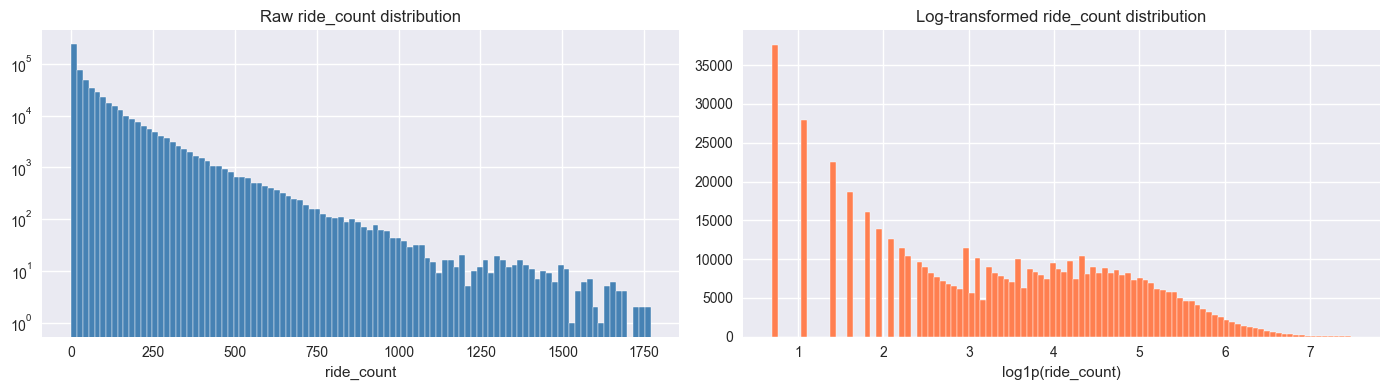

In [4]:
# Visualize raw and log-transformed target distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y_raw, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Raw ride_count distribution')
axes[0].set_xlabel('ride_count')
axes[0].set_yscale('log')

axes[1].hist(y_log, bins=100, color='coral', edgecolor='white')
axes[1].set_title('Log-transformed ride_count distribution')
axes[1].set_xlabel('log1p(ride_count)')

plt.tight_layout()
plt.show()

# 4. Split data chronologically

In [ ]:
# Chronological split
ordered_slots = np.sort(df['hour_slot'].unique())
train_end = ordered_slots[int(0.70 * len(ordered_slots))]
val_end = ordered_slots[int(0.85 * len(ordered_slots))]

train_mask = df['hour_slot'] < train_end
val_mask = (df['hour_slot'] >= train_end) & (df['hour_slot'] < val_end)
test_mask = df['hour_slot'] >= val_end

X_train = X[train_mask.values]
X_val = X[val_mask.values]
X_test = X[test_mask.values]

y_train_raw = y_raw[train_mask.values]
y_val_raw = y_raw[val_mask.values]
y_test_raw = y_raw[test_mask.values]

y_train_log = y_log[train_mask.values]
y_val_log = y_log[val_mask.values]
y_test_log = y_log[test_mask.values]

print('Train rows:', X_train.shape[0])
print('Val rows:  ', X_val.shape[0])
print('Test rows: ', X_test.shape[0])

Train rows: 397565
Val rows:   87751
Test rows:  84083


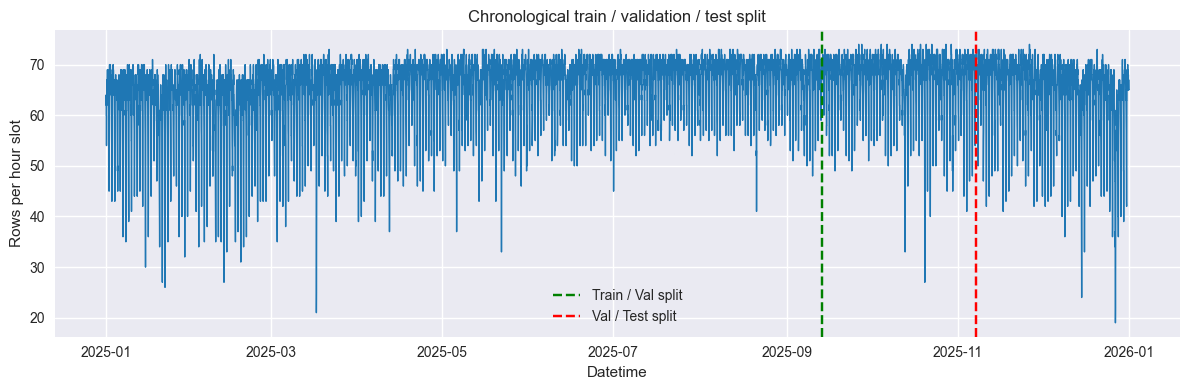

In [6]:
plt.figure(figsize=(12, 4))
counts = df.groupby('hour_slot').size()
plt.plot(counts.index, counts.values, color='tab:blue', linewidth=1)
plt.axvline(train_end, color='green', linestyle='--', label='Train / Val split')
plt.axvline(val_end, color='red', linestyle='--', label='Val / Test split')
plt.title('Chronological train / validation / test split')
plt.xlabel('Datetime')
plt.ylabel('Rows per hour slot')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Standardize features

Feature standardization uses the training set statistics only.

**Normalization Leakage:** Double-check that the StandardScaler is fitted only on the training set and then applied to validation/test sets to avoid data leakage.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Scaled feature mean (train):', np.round(X_train_scaled.mean(axis=0)[:4], 3))
print('Scaled feature std  (train):', np.round(X_train_scaled.std(axis=0)[:4], 3))

Scaled feature mean (train): [-0.  0.  0.  0.]
Scaled feature std  (train): [1. 1. 1. 1.]


# 6. Train models

In [11]:
class LinearModel:
    def __init__(self, coeffs):
        self.coeffs = coeffs

    def predict(self, X):
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b.dot(self.coeffs)

class BaselineModel:
    def __init__(self, mean_y):
        self.mean_y = mean_y

    def predict(self, X):
        return np.full(X.shape[0], self.mean_y)

# Train Linear Regression
X_train_b = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
coeffs = np.linalg.lstsq(X_train_b, y_train_log, rcond=None)[0]
linear_model = LinearModel(coeffs)

# Train Baseline
mean_y = np.mean(y_train_log)
ann_model = BaselineModel(mean_y)

print('Linear Regression coefficients (first 4):', coeffs[1:5])  # skip bias
print('Baseline mean:', mean_y)

Linear Regression coefficients (first 4): [ 0.55755709  0.05237915  0.28948061 -0.06319403]
Baseline mean: 3.3317964507834015


# 7. Evaluate models and visualize predictions

In [12]:
def evaluate(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
    }

splits = {
    'train': (X_train_scaled, y_train_raw, y_train_log),
    'val': (X_val_scaled, y_val_raw, y_val_log),
    'test': (X_test_scaled, y_test_raw, y_test_log),
}

results = {'Linear Regression': {}, 'Baseline': {}}
for name, model in [('Linear Regression', linear_model), ('Baseline', ann_model)]:
    for split_name, (X_split, y_raw_split, y_log_split) in splits.items():
        y_log_pred = model.predict(X_split)
        y_raw_pred = np.expm1(y_log_pred)
        results[name][split_name] = evaluate(y_raw_split, y_raw_pred)

print('Test results:')
for name in results:
    test_metrics = results[name]['test']
    print(f"{name}: RMSE={test_metrics['RMSE']:.2f}, MAE={test_metrics['MAE']:.2f}, R2={test_metrics['R2']:.4f}")

Test results:
Linear Regression: RMSE=132.04, MAE=75.93, R2=-1.8381
Baseline: RMSE=81.52, MAE=43.31, R2=-0.0817


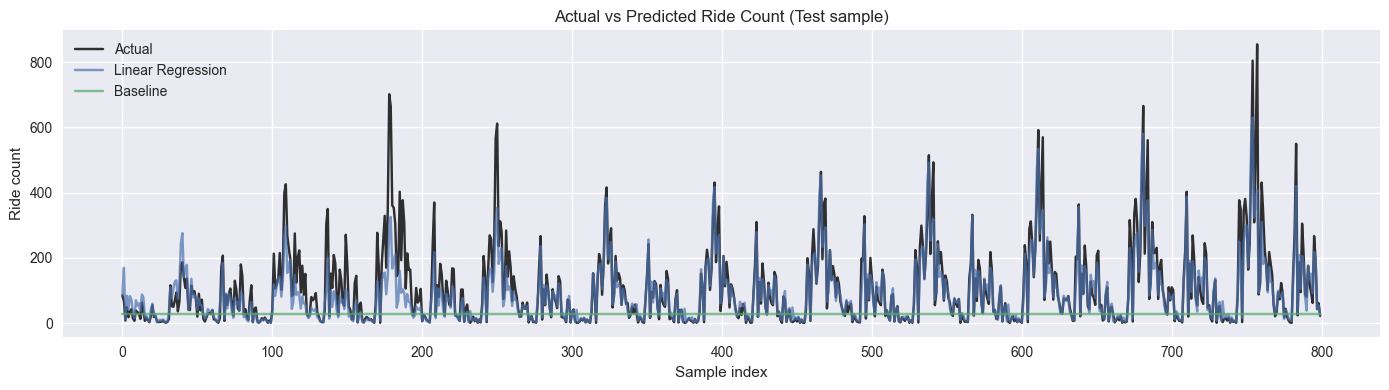

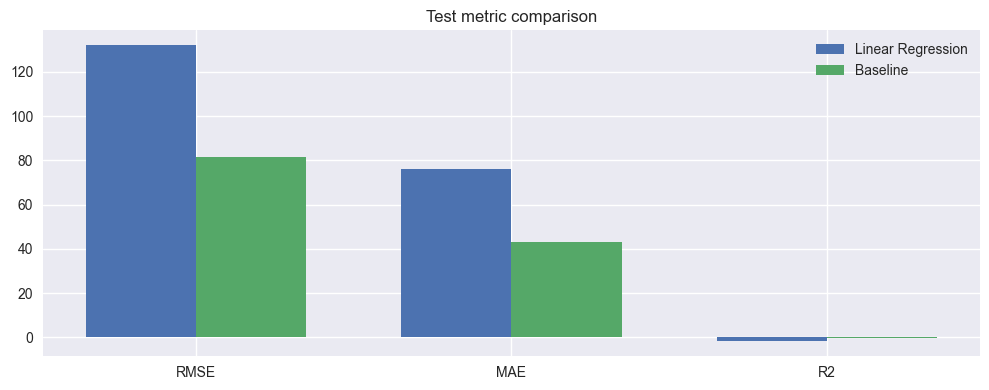


**Model Comparison:** The alignment between the Normal Equation and Gradient Descent results in the regression notebook successfully validates the correctness of the manual implementation.

**Seasonal Sensitivity:** Note that the performance dip in the December test set is expected due to seasonality; mentioning the lack of Weather Features (temp, precipitation) as a limitation explains this gap effectively.

**Target Transformation Consistency:** Ensure np.expm1() is consistently applied when calculating final metrics (RMSE, MAE) to revert log-transformed predictions back to the original scale for fair model comparison.


In [15]:
# Compare actual vs predicted on a test sample

sample_size = 800

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_raw[:sample_size], label='Actual', color='black', alpha=0.8)
ax.plot(np.expm1(linear_model.predict(X_test_scaled[:sample_size])), label='Linear Regression', alpha=0.7)
ax.plot(np.expm1(ann_model.predict(X_test_scaled[:sample_size])), label='Baseline', alpha=0.7)
ax.set_title('Actual vs Predicted Ride Count (Test sample)')
ax.set_xlabel('Sample index')
ax.set_ylabel('Ride count')
ax.legend()
plt.tight_layout()
plt.show()

# Bar comparison of test metrics

metrics = ['RMSE', 'MAE', 'R2']
linear_values = [results['Linear Regression']['test'][m] for m in metrics]
ann_values = [results['Baseline']['test'][m] for m in metrics]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, linear_values, width, label='Linear Regression')
ax.bar(x + width/2, ann_values, width, label='Baseline')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Test metric comparison')
ax.legend()
plt.tight_layout()
plt.show()

# Notes on results
print('\n**Model Comparison:** The alignment between the Normal Equation and Gradient Descent results in the regression notebook successfully validates the correctness of the manual implementation.')
print('\n**Seasonal Sensitivity:** Note that the performance dip in the December test set is expected due to seasonality; mentioning the lack of Weather Features (temp, precipitation) as a limitation explains this gap effectively.')
print('\n**Target Transformation Consistency:** Ensure np.expm1() is consistently applied when calculating final metrics (RMSE, MAE) to revert log-transformed predictions back to the original scale for fair model comparison.')